In [3]:
import pandas as pd 
import matplotlib.pyplot as plt 

In [4]:
df=pd.read_csv('HR.csv')
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [25]:
%matplotlib inline
dfle=df[df.left==1]
dfle.shape

(3571, 10)

In [26]:
dfre=df[df.left==0]
dfre.shape

(11428, 10)

In [5]:
df['left'].value_counts()

left
0    11428
1     3571
Name: count, dtype: int64

<Axes: >

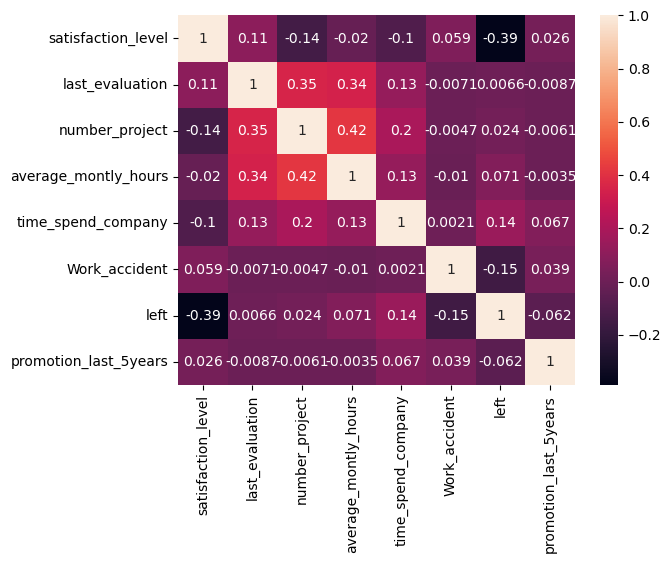

In [7]:
import seaborn as sns

sns.heatmap(df.corr(numeric_only=True),annot=True)

In [27]:
dfne=df.drop(['Department','salary'],axis='columns')
dfne.groupby('left').mean()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years
left,,,,,,,
0,0.666810,0.715473,3.786664,199.060203,3.380032,0.175009,0.026251
1,0.440098,0.718113,3.855503,207.419210,3.876505,0.047326,0.005321


<Axes: xlabel='Department'>

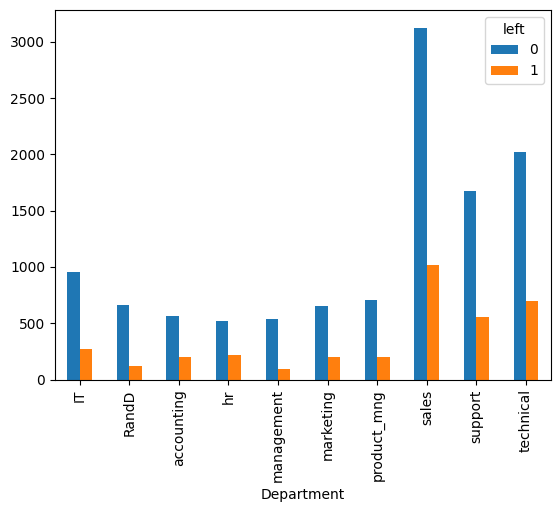

In [28]:
pd.crosstab(df['Department'],df.left).plot(kind='bar')

<Axes: xlabel='Department', ylabel='count'>

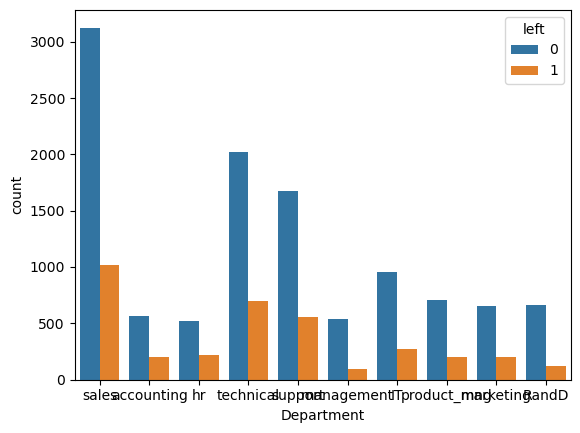

In [ ]:

sns.countplot(x=df['Department'],hue=df['left'])

<Axes: xlabel='salary'>

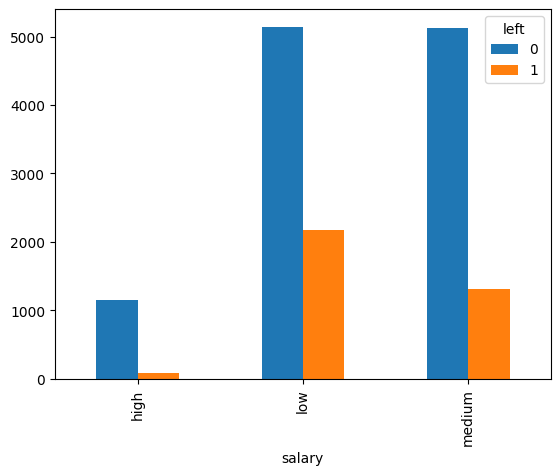

In [29]:
pd.crosstab(df['salary'],df.left).plot(kind='bar')

In [30]:
final=df[['satisfaction_level','average_montly_hours','promotion_last_5years','salary']]
final=final.values
final


array([[0.38, 157, 0, 'low'],
       [0.8, 262, 0, 'medium'],
       [0.11, 272, 0, 'medium'],
       ...,
       [0.37, 143, 0, 'low'],
       [0.11, 280, 0, 'low'],
       [0.37, 158, 0, 'low']], dtype=object)

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Specify which columns to encode (e.g., column index 0)
# 'remainder="passthrough"' keeps the other columns as they are
ct = ColumnTransformer(
    transformers=[('encoder', OneHotEncoder(), [3])], 
    remainder='passthrough'
)


In [32]:
final=ct.fit_transform(final)
final

array([[0.0, 1.0, 0.0, 0.38, 157, 0],
       [0.0, 0.0, 1.0, 0.8, 262, 0],
       [0.0, 0.0, 1.0, 0.11, 272, 0],
       ...,
       [0.0, 1.0, 0.0, 0.37, 143, 0],
       [0.0, 1.0, 0.0, 0.11, 280, 0],
       [0.0, 1.0, 0.0, 0.37, 158, 0]], dtype=object)

In [33]:
final=final[:,1:]
final

array([[1.0, 0.0, 0.38, 157, 0],
       [0.0, 1.0, 0.8, 262, 0],
       [0.0, 1.0, 0.11, 272, 0],
       ...,
       [1.0, 0.0, 0.37, 143, 0],
       [1.0, 0.0, 0.11, 280, 0],
       [1.0, 0.0, 0.37, 158, 0]], dtype=object)

In [34]:
X=final

In [35]:
y=df.left.values
y

array([1, 1, 1, ..., 1, 1, 1], dtype=int64)

In [36]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2)

In [37]:
print(len(X), len(X_train), len(X_test))
print(len(y), len(y_train), len(y_test))


14999 11999 3000
14999 11999 3000


In [38]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()

model.fit(X_train,y_train)


LogisticRegression()

In [39]:
model.score(X_test,y_test)

0.7846666666666666

In [40]:
from sklearn.metrics import confusion_matrix


In [41]:
y_pred=model.predict(X_test)
cm=confusion_matrix(y_test,y_pred)
cm

array([[2140,  143],
       [ 503,  214]], dtype=int64)

In [42]:
y_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [43]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<Axes: >

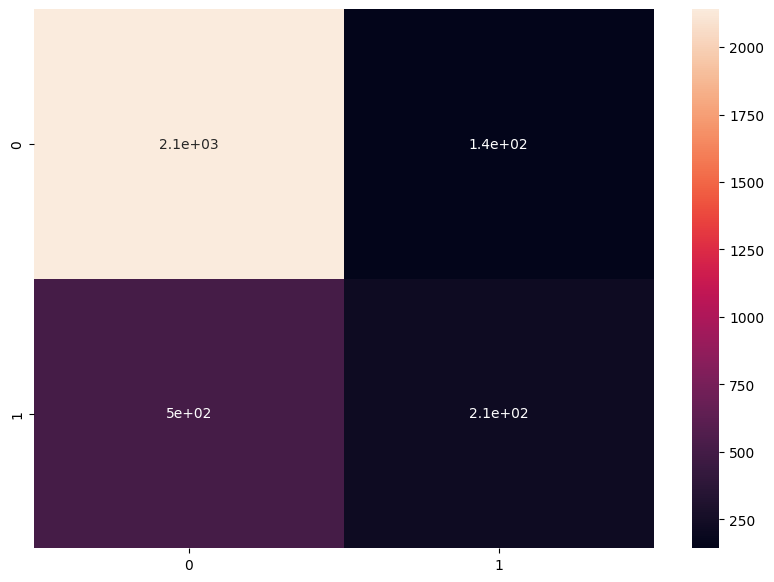

In [44]:
import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm,annot=True)